In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df_raw = pd.read_csv("data/processed/tsla_with_confidence.csv", index_col='Date', parse_dates=True)

# Aggregate tweet-level data to daily trading level
df = df_raw.groupby(df_raw.index).agg({
    'predicted_return': 'mean',
    'confidence_score': 'mean',
    'returns': 'first',
    'Close': 'last'
}).sort_index()

print(f"Final dataset loaded with confidence and predictions. Total trading days: {len(df)}")

Final dataset loaded with confidence and predictions. Total trading days: 39


In [8]:
# Calculate Buy & Hold and Strategy Equity curves on daily portfolio
if 'buy_hold' not in df.columns:
    df['buy_hold'] = 100000 * (df['Close'] / df['Close'].iloc[0])

def run_rule_based(df, confidence_threshold=0.35, base_pos=0.15, initial_capital=100000, transaction_cost=0.001):
    df = df.copy()
    df['position'] = 0.0
    df['strategy_return'] = 0.0
    equity = [initial_capital]
    capital = initial_capital
    
    for i in range(1, len(df)):
        pred = df['predicted_return'].iloc[i]
        conf = df['confidence_score'].iloc[i]
        
        if conf > confidence_threshold and pred > 0.002:
            position = base_pos * conf
        elif conf < 0.35 or pred < -0.005:
            position = 0.0
        else:
            position = 0.1 * conf
            
        cost = abs(position - df['position'].iloc[i-1]) * transaction_cost
        daily_ret = (df['returns'].iloc[i] * position) - cost
        
        capital = capital * (1 + daily_ret)
        equity.append(capital)
        df.iloc[i, df.columns.get_loc('position')] = position
        df.iloc[i, df.columns.get_loc('strategy_return')] = daily_ret
    
    df['equity_rule'] = equity
    return df
df = run_rule_based(df)

def compute_performance_metrics(df, strategy_col='equity_rule', initial_capital=100000):
    equity = df[strategy_col]
    returns = equity.pct_change().dropna()
    
    total_return = (equity.iloc[-1] / initial_capital - 1) * 100
    ann_return = returns.mean() * 252 * 100
    ann_vol = returns.std() * np.sqrt(252) * 100
    sharpe = returns.mean() / (returns.std() + 1e-8) * np.sqrt(252)
    max_dd = (equity / equity.cummax() - 1).min() * 100
    calmar = total_return / abs(max_dd) if max_dd != 0 else 0
    win_rate = (returns > 0).mean() * 100
    
    metrics = {
        "Total Return (%)": round(total_return, 2),
        "Annualized Return (%)": round(ann_return, 2),
        "Annualized Volatility (%)": round(ann_vol, 2),
        "Sharpe Ratio": round(sharpe, 3),
        "Max Drawdown (%)": round(max_dd, 2),
        "Calmar Ratio": round(calmar, 3),
        "Win Rate (%)": round(win_rate, 2),
        "Number of Trades": len(df[df['position'].abs() > 0.01]) if 'position' in df.columns else "N/A"
    }
    return pd.Series(metrics)

# Compare all strategies
print("=== PERFORMANCE SUMMARY ===")
bh_metrics = compute_performance_metrics(df, 'buy_hold')
rule_metrics = compute_performance_metrics(df, 'equity_rule')

comparison = pd.DataFrame({
    "Buy & Hold": bh_metrics,
    "XAI-RL Strategy": rule_metrics
})

print(comparison.round(3))
os.makedirs("results", exist_ok=True)
comparison.to_csv("results/performance_comparison.csv")


=== PERFORMANCE SUMMARY ===
                           Buy & Hold  XAI-RL Strategy
Total Return (%)               -9.570           -0.990
Annualized Return (%)         -45.620           -6.260
Annualized Volatility (%)      65.110            8.230
Sharpe Ratio                   -0.701           -0.761
Max Drawdown (%)              -26.830           -3.960
Calmar Ratio                   -0.357           -0.250
Win Rate (%)                   52.630           31.580
Number of Trades               23.000           23.000


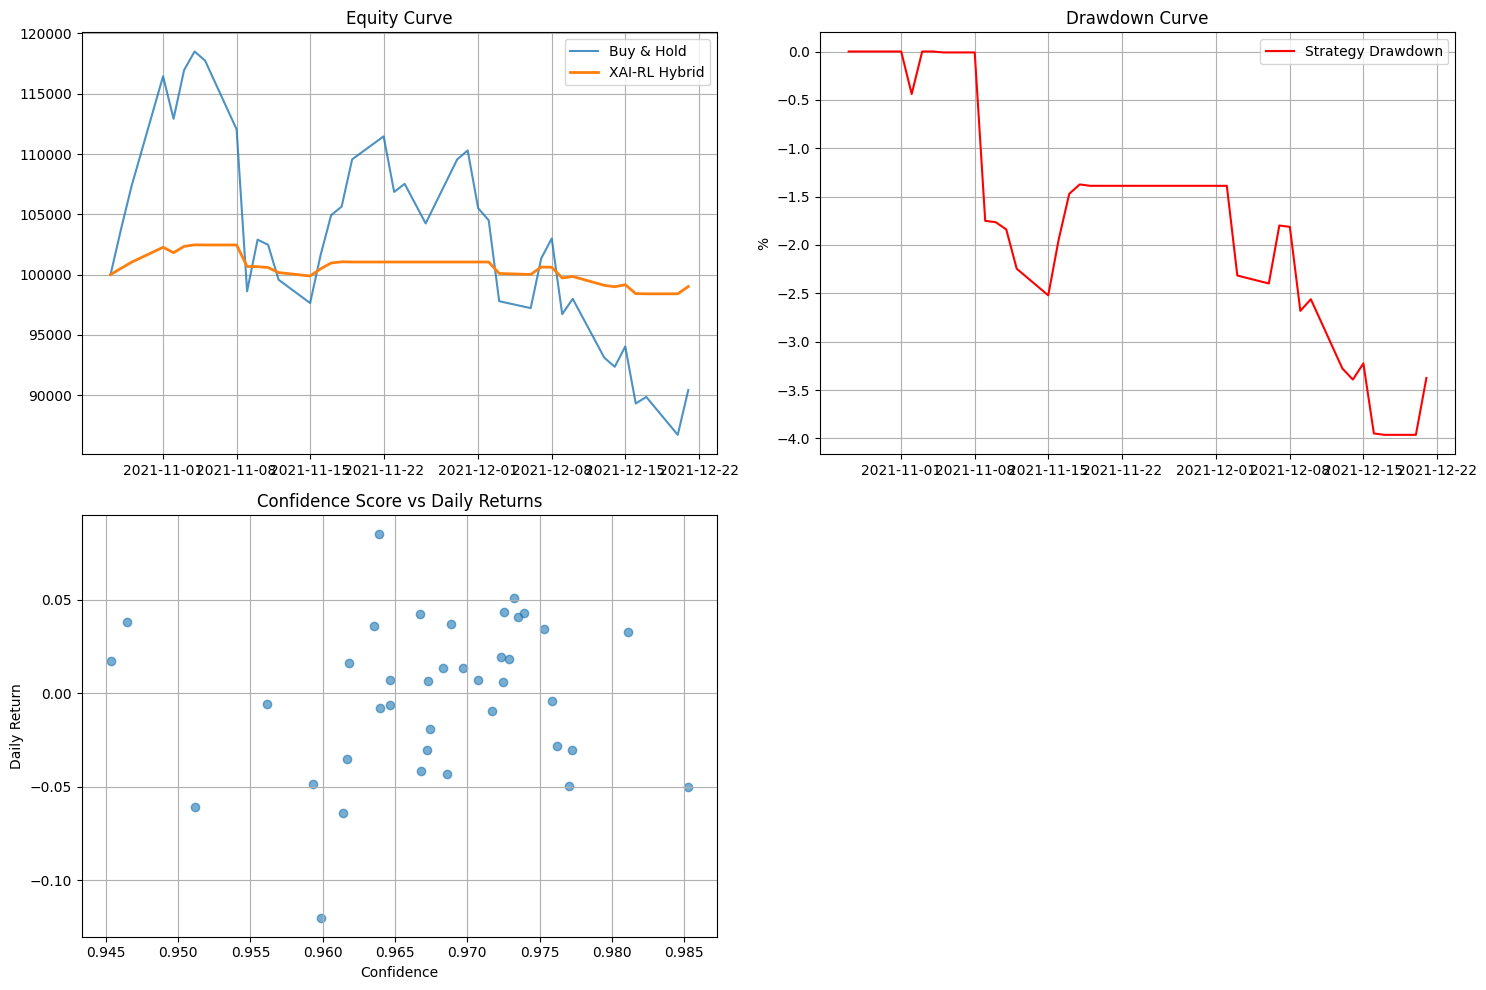

In [9]:
plt.figure(figsize=(15, 10))

# Equity Curve
plt.subplot(2, 2, 1)
plt.plot(df.index, df['buy_hold'], label='Buy & Hold', alpha=0.8)
plt.plot(df.index, df['equity_rule'], label='XAI-RL Hybrid', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)

# Drawdown
plt.subplot(2, 2, 2)
drawdown = df['equity_rule'] / df['equity_rule'].cummax() - 1
plt.plot(df.index, drawdown * 100, label='Strategy Drawdown', color='red')
plt.title('Drawdown Curve')
plt.ylabel('%')
plt.legend()
plt.grid(True)

# Confidence vs Returns
plt.subplot(2, 2, 3)
plt.scatter(df['confidence_score'], df['returns'], alpha=0.6)
plt.title('Confidence Score vs Daily Returns')
plt.xlabel('Confidence')
plt.ylabel('Daily Return')
plt.grid(True)

plt.tight_layout()
plt.savefig("results/final_analysis_plots.png", dpi=200)
plt.show()

In [10]:
best_params = globals().get('best_params', {'threshold': 0.35, 'base_position': 0.15})

summary = f"""
XAI-RL Framework Replication Results (TSLA 2021-2022)

Best Parameters:
- Confidence Threshold : {best_params.get('threshold', 'N/A')}
- Base Position Size   : {best_params.get('base_position', 'N/A')}

Key Metrics:
- Total Return (Strategy): {rule_metrics['Total Return (%)']}%
- Sharpe Ratio           : {rule_metrics['Sharpe Ratio']}
- Max Drawdown           : {rule_metrics['Max Drawdown (%)']}%
- Calmar Ratio           : {rule_metrics['Calmar Ratio']}

Comparison vs Buy & Hold: {'Outperformed' if rule_metrics['Sharpe Ratio'] > bh_metrics['Sharpe Ratio'] else 'Underperformed'}
"""

import os
os.makedirs("results", exist_ok=True)
with open("results/replication_summary.txt", "w") as f:
    f.write(summary)

print(summary)


XAI-RL Framework Replication Results (TSLA 2021-2022)

Best Parameters:
- Confidence Threshold : 0.35
- Base Position Size   : 0.15

Key Metrics:
- Total Return (Strategy): -0.99%
- Sharpe Ratio           : -0.761
- Max Drawdown           : -3.96%
- Calmar Ratio           : -0.25

Comparison vs Buy & Hold: Underperformed

